In [5]:
import pandas as pd

df_all = pd.read_parquet("../0_data/processed_data/data_with_all_features_scaled.parquet")

aligned_data = df_all.loc[df_all.index, ['SMILES', 'MP_label']]


smiles_list = aligned_data['SMILES'].tolist()
labels = aligned_data['MP_label'].values

In [7]:
aligned_data

,SMILES,MP_label
0,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,L
1,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,H
2,Cc1cc(Br)c(cc1Br)C,L
3,OC(=O)c1ccc(c(c1)F)C,L
4,OC(=O)C1CC(=O)c2c1cccc2,L
...,...,...
17215,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,L
17216,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,L
17217,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],L
17218,OC(=O)C(C(=O)O)Cc1ccccc1,L


In [14]:
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator  # Import the new generator module

def get_morgan_similarity_matrix(smiles_list, radius=2, n_bits=2048):
    # 1. Initialize the Morgan Generator
    # Note: radius=2 here is equivalent to ECFP4
    mfgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    
    # 2. Convert SMILES to Molecule objects
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if s]
    
    # 3. Generate Fingerprints using the generator
    fps = [mfgen.GetFingerprint(m) for m in mols if m is not None]
    
    # 4. Calculate the Pairwise Tanimoto Similarity Matrix
    n = len(fps)
    matrix = np.zeros((n, n))
    for i in range(n):
        # DataStructs.BulkTanimotoSimilarity still works with the new objects
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
        matrix[i] = sims
        
    return matrix

morgan_sim_matrix = get_morgan_similarity_matrix(smiles_list)

In [18]:
def get_matrix_stats(matrix):
    # np.triu_indices gets the coordinates of the upper triangle, 
    # k=1 excludes the diagonal (the 1.0s)
    indices = np.triu_indices(len(matrix), k=1)
    pairwise_values = matrix[indices]
    
    return np.mean(pairwise_values), np.std(pairwise_values)


# Assuming labels_numeric: 1 for 'H', 0 for 'L'
high_idx = np.where(labels_numeric == 1)[0]
low_idx = np.where(labels_numeric == 0)[0]

# Extract the sub-matrices
matrix_high = morgan_sim_matrix[np.ix_(high_idx, high_idx)]
matrix_low = morgan_sim_matrix[np.ix_(low_idx, low_idx)]

# Calculate stats
mean_h, std_h = get_matrix_stats(matrix_high)
mean_l, std_l = get_matrix_stats(matrix_low)

print(f"High MP: Mean Similarity = {mean_h:.4f}, Std = {std_h:.4f}")
print(f"Low MP:  Mean Similarity = {mean_l:.4f}, Std = {std_l:.4f}")

High MP: Mean Similarity = 0.1021, Std = 0.0620
Low MP:  Mean Similarity = 0.0968, Std = 0.0597


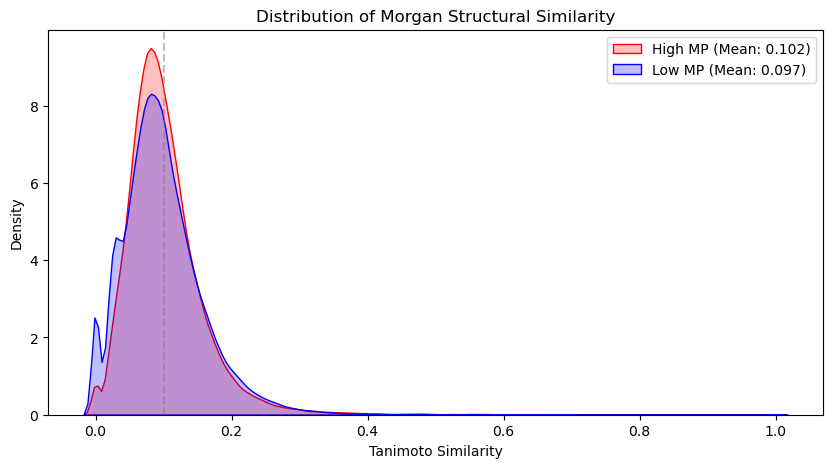

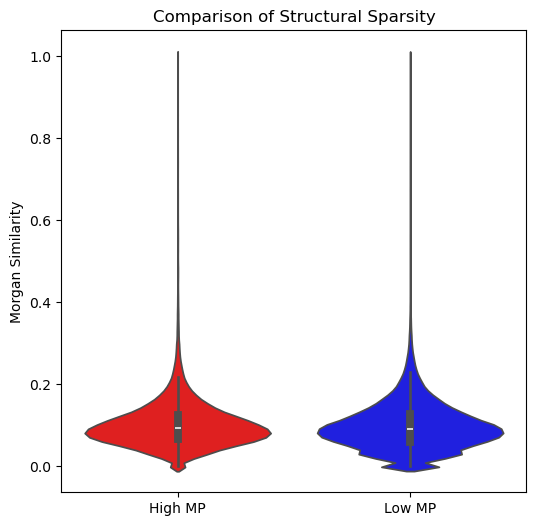

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_similarity_analysis(matrix, labels, sample_size=500):
    # 1. Extract similarities for each class
    def get_sampled_sims(target_label):
        idx = np.where(labels == target_label)[0]
        # Sample to avoid memory issues with 11k molecules
        if len(idx) > sample_size:
            idx = np.random.choice(idx, sample_size, replace=False)
        sub_matrix = matrix[np.ix_(idx, idx)]
        # Get off-diagonal elements
        return sub_matrix[np.tril_indices(len(idx), k=-1)]

    h_sims = get_sampled_sims('H')
    l_sims = get_sampled_sims('L')

    # --- Plot 1: KDE Distribution ---
    plt.figure(figsize=(10, 5))
    sns.kdeplot(h_sims, label='High MP (Mean: 0.102)', fill=True, color='red')
    sns.kdeplot(l_sims, label='Low MP (Mean: 0.097)', fill=True, color='blue')
    plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5)
    plt.title('Distribution of Morgan Structural Similarity')
    plt.xlabel('Tanimoto Similarity')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    # --- Plot 2: Violin Plot ---
    plt.figure(figsize=(6, 6))
    data_to_plot = [h_sims, l_sims]
    sns.violinplot(data=data_to_plot, palette=['red', 'blue'])
    plt.xticks([0, 1], ['High MP', 'Low MP'])
    plt.ylabel('Morgan Similarity')
    plt.title('Comparison of Structural Sparsity')
    plt.show()

# Run the visualization
plot_similarity_analysis(morgan_sim_matrix, labels)

In [15]:
from vendi_score import vendi

# Calculate the diversity of the entire dataset
vendi_structural = vendi.score_K(morgan_sim_matrix)

print(f"Total Molecules: {len(morgan_sim_matrix)}")
print(f"Vendi Structural Diversity: {vendi_structural:.2f}")

Total Molecules: 17220
Vendi Structural Diversity: 1754.15


In [16]:
# Convert strings to numbers: High = 1, Low = 0
labels_numeric = np.where(aligned_data['MP_label'] == 'H', 1, 0)

# Verify the counts
print(f"High MP (1): {np.sum(labels_numeric == 1)}")
print(f"Low MP (0): {np.sum(labels_numeric == 0)}")

High MP (1): 878
Low MP (0): 16342


In [17]:
from vendi_score import vendi

# Get indices for each class
high_idx = np.where(labels_numeric == 1)[0]
low_idx = np.where(labels_numeric == 0)[0]

# Slice the Morgan Similarity Matrix
matrix_high = morgan_sim_matrix[np.ix_(high_idx, high_idx)]
matrix_low = morgan_sim_matrix[np.ix_(low_idx, low_idx)]

# Calculate Vendi Scores
vendi_high = vendi.score_K(matrix_high)
vendi_low = vendi.score_K(matrix_low)

print(f"Vendi Score (High MP): {vendi_high:.2f}")
print(f"Vendi Score (Low MP): {vendi_low:.2f}")

Vendi Score (High MP): 339.08
Vendi Score (Low MP): 1702.32
